# Colab 시작 페이지

In [5]:
# ============================================================
# 0. Import Libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tarfile
import pickle
import os

from google.colab import files
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ============================================================
# 1. Upload CIFAR-10 File
# ============================================================

uploaded = files.upload()

# 업로드한 파일 이름 확인
print(uploaded.keys())

import os

# 파일 이름에 (1) 붙은 것 제거
for fname in os.listdir():
    if "(1)" in fname:
        new_name = fname.replace(" (1)", "")
        os.rename(fname, new_name)

print("After rename:", os.listdir())

Saving data_batch_4 to data_batch_4
Saving data_batch_1 to data_batch_1
Saving data_batch_5 to data_batch_5
Saving data_batch_2 to data_batch_2
Saving data_batch_3 to data_batch_3
Saving test_batch to test_batch
dict_keys(['data_batch_4', 'data_batch_1', 'data_batch_5', 'data_batch_2', 'data_batch_3', 'test_batch'])
After rename: ['.config', 'data_batch_3', 'data_batch_1', 'data_batch_2', 'data_batch_4', 'test_batch', 'data_batch_5', 'sample_data']


In [6]:
# ============================================================
# 3. Load CIFAR-10 Dataset from Extracted Files
# ============================================================

data_dir = "."

def load_batch(file_path):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="latin1")

    X = batch["data"]
    y = np.array(batch["labels"])

    return X, y

# Load training batches: data_batch_1 ~ data_batch_5
X_train_list = []
y_train_list = []

for i in range(1, 6):
    file_path = os.path.join(data_dir, f"data_batch_{i}")
    X_batch, y_batch = load_batch(file_path)
    X_train_list.append(X_batch)
    y_train_list.append(y_batch)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

# Load test batch
X_test, y_test = load_batch(os.path.join(data_dir, "test_batch"))

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)


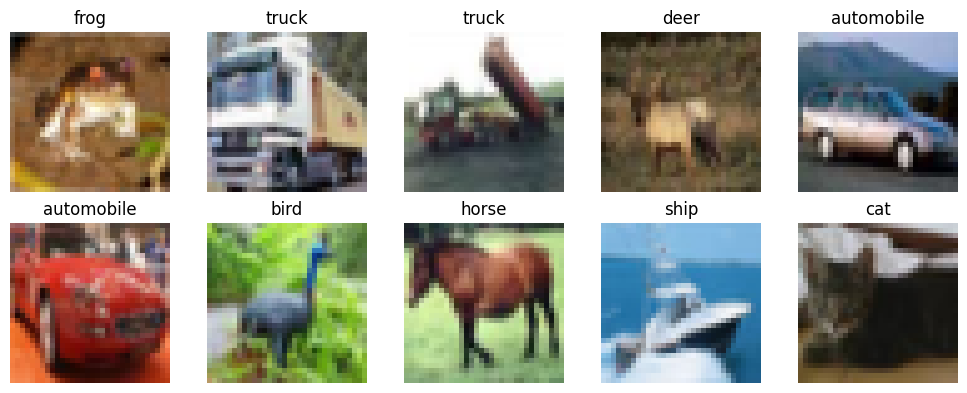

In [7]:
# ============================================================
# 4. Visualize Sample Images
# ============================================================

plt.figure(figsize=(10, 4))

for i in range(10):
    img = X_train[i].reshape(3, 32, 32).transpose(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 5. Use Small Subset
# ============================================================

num_train = 5000
num_test = 1000

X_train_small = X_train[:num_train].astype(np.float32)
y_train_small = y_train[:num_train]

X_test_small = X_test[:num_test].astype(np.float32)
y_test_small = y_test[:num_test]

print("Training subset shape:", X_train_small.shape)
print("Test subset shape:", X_test_small.shape)
print("Training labels shape:", y_train_small.shape)
print("Test labels shape:", y_test_small.shape)

Training subset shape: (5000, 3072)
Test subset shape: (1000, 3072)
Training labels shape: (5000,)
Test labels shape: (1000,)


In [9]:
# ============================================================
# 6. Implement KNN Classifier from Scratch
# ============================================================

class KNNClassifier:
    def __init__(self, k=1, distance_metric="l2"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def compute_distances(self, X_test):
      num_test = X_test.shape[0]
      num_train = self.X_train.shape[0]

      distances = np.zeros((num_test, num_train))

      for i in range(num_test):
          if self.distance_metric == "l1":
              distances[i] = np.sum(
                  np.abs(self.X_train - X_test[i]),
                  axis=1
              )

          elif self.distance_metric == "l2":
              distances[i] = np.sqrt(
                  np.sum(
                      (self.X_train - X_test[i]) ** 2,
                      axis=1
                  )
              )

      return distances

    def predict(self, X_test):
        distances = self.compute_distances(X_test)
        num_test = X_test.shape[0]
        y_pred = np.zeros(num_test, dtype=int)

        for i in range(num_test):
            nearest_indices = np.argsort(distances[i])[:self.k]
            nearest_labels = self.y_train[nearest_indices]

            label_counts = np.bincount(nearest_labels, minlength=10)
            y_pred[i] = np.argmax(label_counts)

        return y_pred

In [10]:
# ============================================================
# 7. Accuracy Function
# ============================================================

def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [11]:
# ============================================================
# 8. Test Different K Values and Distance Metrics
# ============================================================

k_values = [1, 3, 5, 7, 9]
distance_metrics = ["l1", "l2"]

results = []

best_accuracy = 0
best_k = None
best_metric = None
best_predictions = None

for metric in distance_metrics:
    for k in k_values:
        print(f"Running KNN with distance metric = {metric.upper()}, K = {k}")

        knn = KNNClassifier(k=k, distance_metric=metric)
        knn.fit(X_train_small, y_train_small)

        y_pred = knn.predict(X_test_small)
        accuracy = accuracy_score_manual(y_test_small, y_pred)

        results.append({
            "Distance Metric": metric.upper(),
            "K": k,
            "Accuracy": accuracy
        })

        print(f"Accuracy: {accuracy:.4f}")
        print("-" * 50)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
            best_metric = metric
            best_predictions = y_pred

print("Experiment completed.")
print(f"Best model: {best_metric.upper()}, K = {best_k}, Accuracy = {best_accuracy:.4f}")

Running KNN with distance metric = L1, K = 1
Accuracy: 0.2880
--------------------------------------------------
Running KNN with distance metric = L1, K = 3
Accuracy: 0.2780
--------------------------------------------------
Running KNN with distance metric = L1, K = 5
Accuracy: 0.3100
--------------------------------------------------
Running KNN with distance metric = L1, K = 7
Accuracy: 0.3090
--------------------------------------------------
Running KNN with distance metric = L1, K = 9
Accuracy: 0.3010
--------------------------------------------------
Running KNN with distance metric = L2, K = 1
Accuracy: 0.2680
--------------------------------------------------
Running KNN with distance metric = L2, K = 3
Accuracy: 0.2610
--------------------------------------------------
Running KNN with distance metric = L2, K = 5
Accuracy: 0.2660
--------------------------------------------------
Running KNN with distance metric = L2, K = 7
Accuracy: 0.2740
----------------------------------

In [12]:
# ============================================================
# 9. Report Accuracy Table
# ============================================================

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))
results_df

Distance Metric  K  Accuracy
             L1  1     0.288
             L1  3     0.278
             L1  5     0.310
             L1  7     0.309
             L1  9     0.301
             L2  1     0.268
             L2  3     0.261
             L2  5     0.266
             L2  7     0.274
             L2  9     0.270


,Distance Metric,K,Accuracy
0,L1,1,0.288
1,L1,3,0.278
2,L1,5,0.310
3,L1,7,0.309
4,L1,9,0.301
5,L2,1,0.268
6,L2,3,0.261
7,L2,5,0.266
8,L2,7,0.274
9,L2,9,0.270


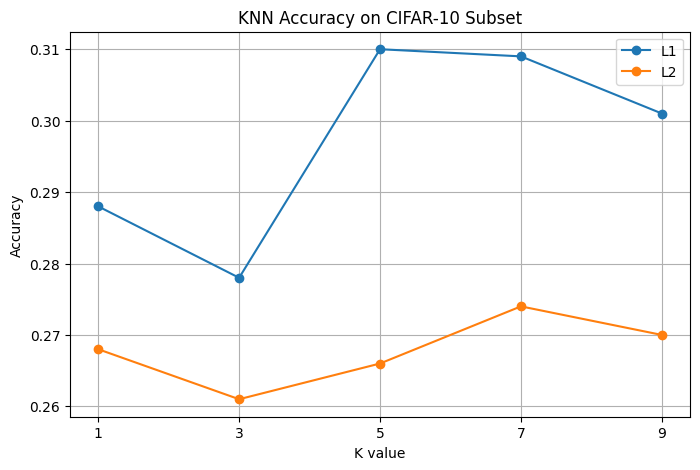

In [13]:
# ============================================================
# 10. Plot Accuracy Results
# ============================================================

plt.figure(figsize=(8, 5))

for metric in distance_metrics:
    metric_results = results_df[results_df["Distance Metric"] == metric.upper()]

    plt.plot(
        metric_results["K"],
        metric_results["Accuracy"],
        marker="o",
        label=metric.upper()
    )

plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy on CIFAR-10 Subset")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

Best Model: Distance Metric = L1, K = 5
Best Accuracy: 0.3100


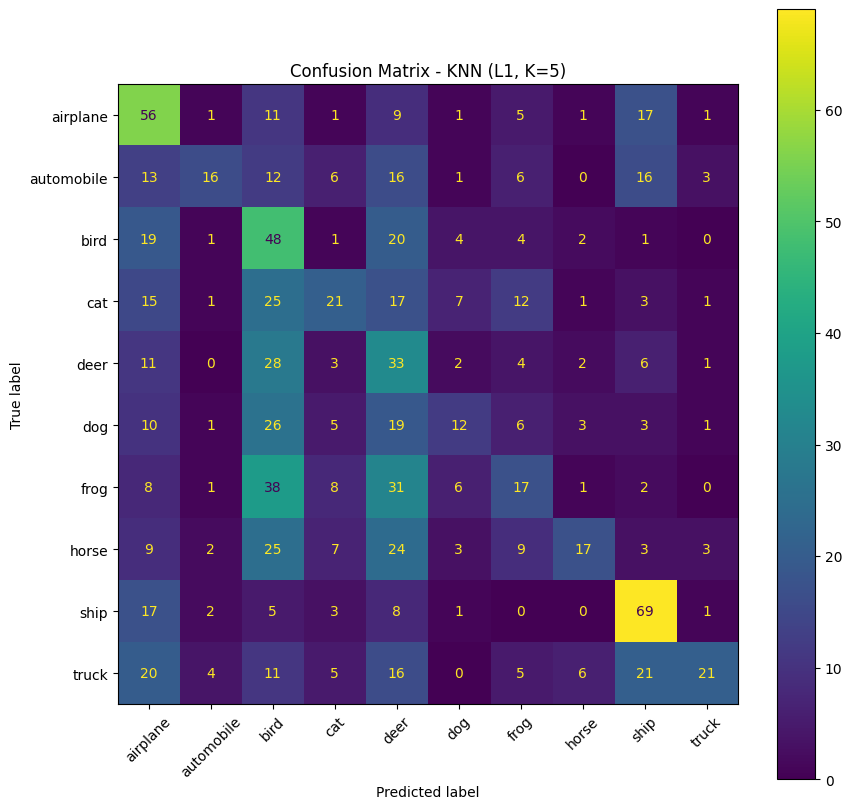

In [14]:
# ============================================================
# 11. Confusion Matrix for Best Model
# ============================================================

print(f"Best Model: Distance Metric = {best_metric.upper()}, K = {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

cm = confusion_matrix(y_test_small, best_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix - KNN ({best_metric.upper()}, K={best_k})")
plt.show()

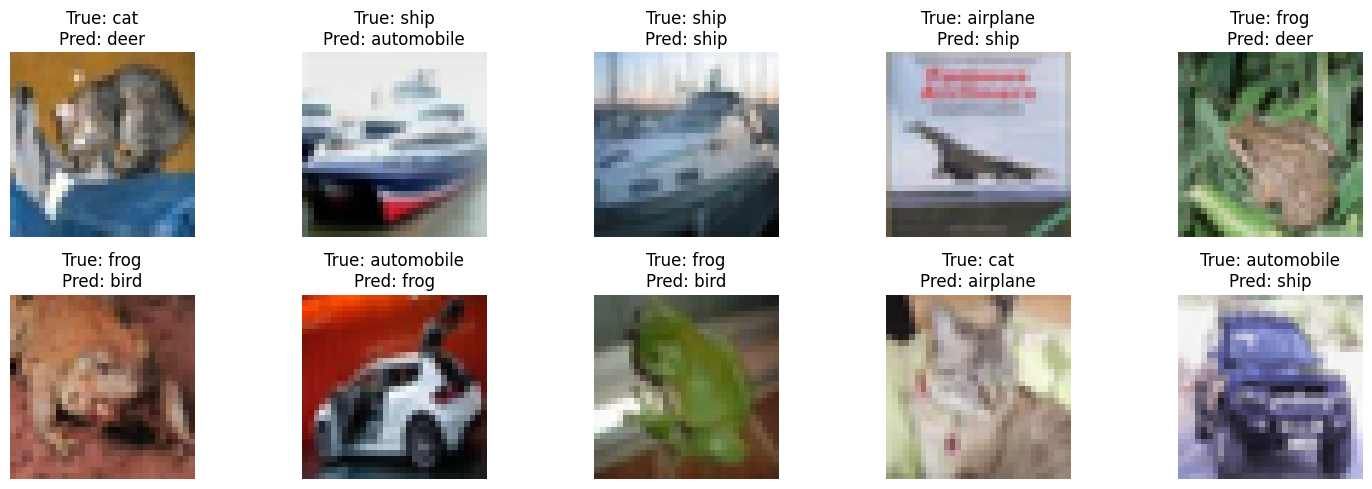

In [16]:
# ============================================================
# 12. Show Prediction Examples
# ============================================================

plt.figure(figsize=(15, 5))

for i in range(10):
    img = X_test_small[i].reshape(3, 32, 32).transpose(1, 2, 0)
    img = img / 255.0

    true_label = class_names[y_test_small[i]]
    pred_label = class_names[best_predictions[i]]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()